In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mohammedjaveed/loveda-dataset/Val/Val/Rural/masks_png/2664.png
/kaggle/input/datasets/mohammedjaveed/loveda-dataset/Val/Val/Rural/masks_png/2539.png
/kaggle/input/datasets/mohammedjaveed/loveda-dataset/Val/Val/Rural/masks_png/3217.png
/kaggle/input/datasets/mohammedjaveed/loveda-dataset/Val/Val/Rural/masks_png/3207.png
/kaggle/input/datasets/mohammedjaveed/loveda-dataset/Val/Val/Rural/masks_png/2673.png
/kaggle/input/datasets/mohammedjaveed/loveda-dataset/Val/Val/Rural/masks_png/2823.png
/kaggle/input/datasets/mohammedjaveed/loveda-dataset/Val/Val/Rural/masks_png/2851.png
/kaggle/input/datasets/mohammedjaveed/loveda-dataset/Val/Val/Rural/masks_png/3448.png
/kaggle/input/datasets/mohammedjaveed/loveda-dataset/Val/Val/Rural/masks_png/2982.png
/kaggle/input/datasets/mohammedjaveed/loveda-dataset/Val/Val/Rural/masks_png/3152.png
/kaggle/input/datasets/mohammedjaveed/loveda-dataset/Val/Val/Rural/masks_png/2690.png
/kaggle/input/datasets/mohammedjaveed/loveda-dataset/V

## installation

In [3]:
!pip install segmentation-models-pytorch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.5 MB/s eta 0:00:00


## Collect image and mask file paths

Build sorted lists of image/mask file paths for the Train and Val splits, matching each image to its corresponding mask by filename. The Test split is excluded here since it has no ground-truth masks.

In [4]:
import glob

DATA_ROOT = "/kaggle/input/datasets/mohammedjaveed/loveda-dataset"

def collect_paths(split, scenes=("Rural", "Urban")):
    images, masks = [], []
    for scene in scenes:
        img_dir = f"{DATA_ROOT}/{split}/{split}/{scene}/images_png"
        mask_dir = f"{DATA_ROOT}/{split}/{split}/{scene}/masks_png"
        imgs = sorted(glob.glob(f"{img_dir}/*.png"))
        for p in imgs:
            fname = p.split("/")[-1]
            images.append(p)
            masks.append(f"{mask_dir}/{fname}")
    return images, masks

train_images, train_masks = collect_paths("Train")
val_images, val_masks = collect_paths("Val")

print("train:", len(train_images), "val:", len(val_images))

train: 2522 val: 1669


## Inspect dataset size and format

Check the number of images in each split, and inspect one image/mask pair to confirm dimensions, color mode, and the set of class label values present in the mask.

In [5]:
from PIL import Image
import numpy as np

print("Train:", len(train_images), "images")
print("Val:", len(val_images), "images")

img = Image.open(train_images[0])
mask = Image.open(train_masks[0])
print("image size:", img.size, "mode:", img.mode)
print("mask size:", mask.size, "mode:", mask.mode)
print("mask unique values:", np.unique(np.array(mask)))

Train: 2522 images
Val: 1669 images
image size: (1024, 1024) mode: RGB
mask size: (1024, 1024) mode: L
mask unique values: [1 2 3 4 7]


## Visualize sample images, masks, and class distributions

Randomly sample a few image/mask pairs and display the raw image, the color-coded segmentation mask, an overlay of the two, and a per-image histogram of class pixel counts.

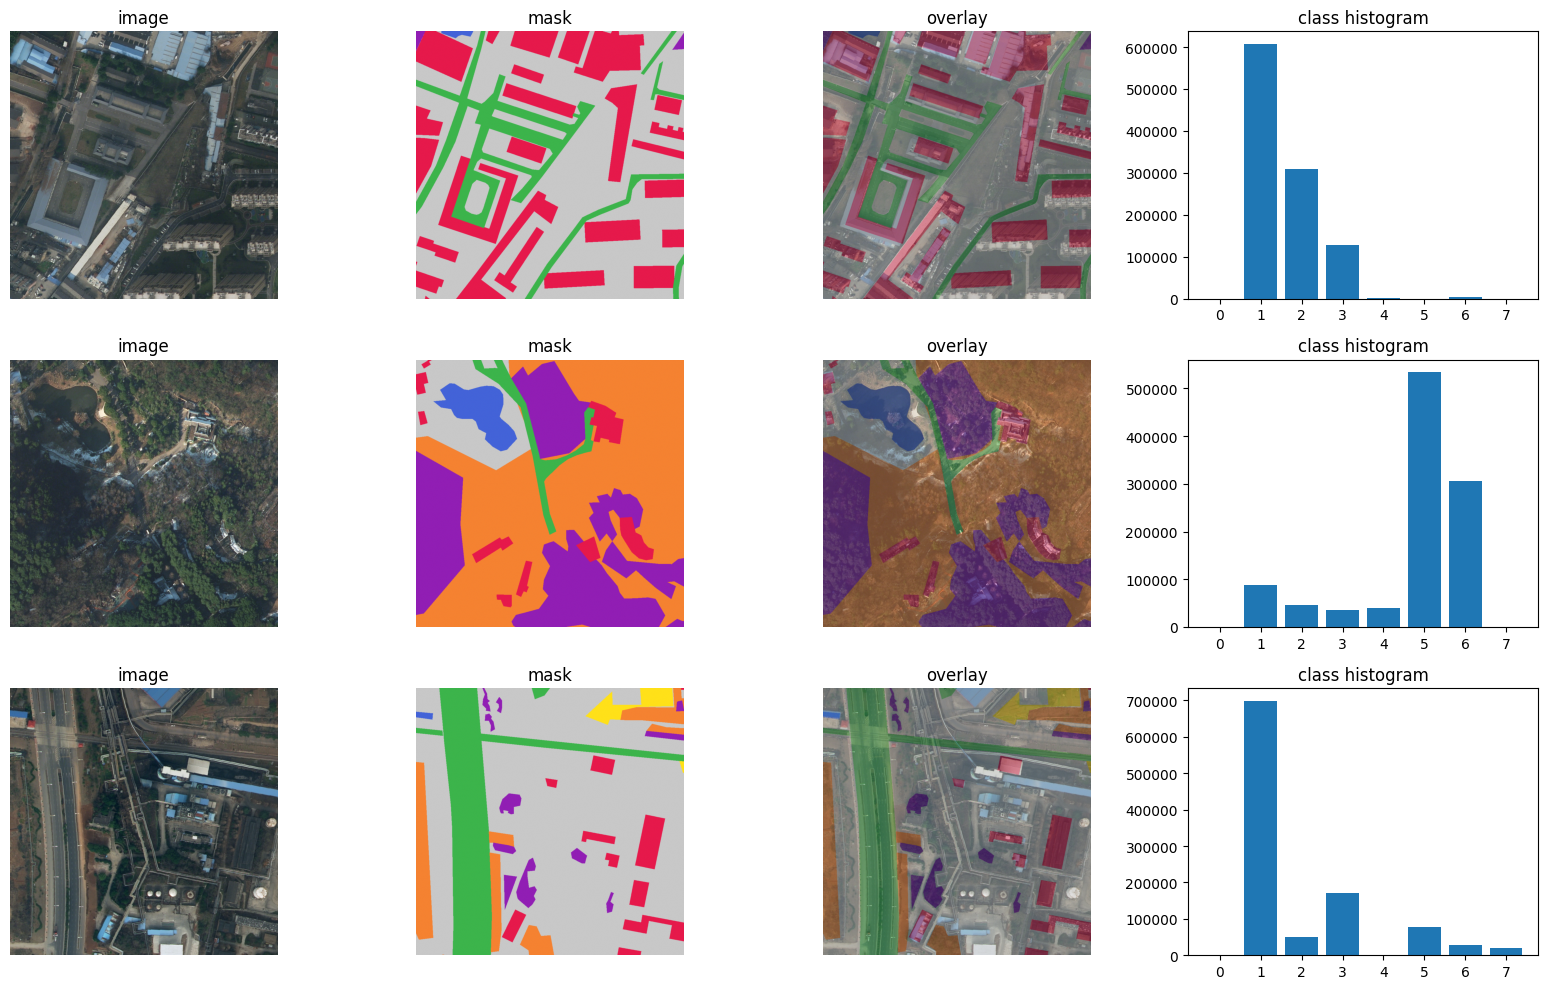

In [6]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

CLASS_NAMES = ["no-data", "background", "building", "road", "water", "barren", "forest", "agriculture"]
CLASS_COLORS = ["black", "#c8c8c8", "#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4", "#ffe119"]
cmap = ListedColormap(CLASS_COLORS)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for i in range(3):
    idx = np.random.randint(len(train_images))
    img = np.array(Image.open(train_images[idx]).convert("RGB"))
    mask = np.array(Image.open(train_masks[idx]))
    axes[i,0].imshow(img); axes[i,0].set_title("image"); axes[i,0].axis("off")
    axes[i,1].imshow(mask, cmap=cmap, vmin=0, vmax=7); axes[i,1].set_title("mask"); axes[i,1].axis("off")
    axes[i,2].imshow(img); axes[i,2].imshow(mask, cmap=cmap, vmin=0, vmax=7, alpha=0.4)
    axes[i,2].set_title("overlay"); axes[i,2].axis("off")
    axes[i,3].hist(mask.flatten(), bins=range(9), align="left", rwidth=0.8)
    axes[i,3].set_xticks(range(8)); axes[i,3].set_title("class histogram")
plt.tight_layout()
plt.show()

## Check overall class balance

Sample a subset of training masks and compute the percentage of total pixels belonging to each class, to quantify how imbalanced the dataset is across the 7 land-cover categories.

In [7]:
from collections import Counter
import random

sample_paths = random.sample(train_masks, 200)  # subset for speed
counts = Counter()
for p in sample_paths:
    m = np.array(Image.open(p))
    vals, cnts = np.unique(m, return_counts=True)
    for v, c in zip(vals, cnts):
        counts[v] += c

total = sum(counts.values())
for c in range(8):
    print(f"{CLASS_NAMES[c]:12s}: {100*counts.get(c,0)/total:5.2f}%")

no-data     :  3.77%
background  : 31.65%
building    : 11.31%
road        :  5.35%
water       :  5.47%
barren      :  5.20%
forest      : 14.69%
agriculture : 22.56%


## Compare scene types and verify image dimensions

Count how many training images belong to the Urban vs. Rural scenes, and confirm that image dimensions are consistent across a random sample of files.

In [8]:
urban_masks = [p for p in train_masks if "/Urban/" in p]
rural_masks = [p for p in train_masks if "/Rural/" in p]
print("Urban:", len(urban_masks), " Rural:", len(rural_masks))

# repeat the class-histogram code above separately on a sample from each

Urban: 1156  Rural: 1366


In [9]:
sizes = set()
for p in random.sample(train_images, 50):
    sizes.add(Image.open(p).size)
print("distinct sizes found:", sizes)

distinct sizes found: {(1024, 1024)}


## Define the point-supervised segmentation dataset

A PyTorch `Dataset` that loads an image and its full ground-truth mask, applies an optional transform, and simulates sparse point annotations by sampling a fixed number of labeled pixels per class present in the mask (class 0, no-data, is always excluded).

In [10]:
import numpy as np, torch
from torch.utils.data import Dataset
from PIL import Image
import albumentations as A


class SegmentationDataset(Dataset):
    def __init__(self, image_paths, mask_paths, points_per_class=10,
                 strategy="balanced", n_random_points=None, transform=None):
        self.image_paths, self.mask_paths = image_paths, mask_paths
        self.points_per_class = points_per_class
        self.strategy = strategy                # "balanced" or "random"
        self.n_random_points = n_random_points   # used only when strategy="random"
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def _sample_points_balanced(self, mask):
        point_mask = np.zeros_like(mask, dtype=np.float32)
        for c in np.unique(mask):
            if c == 0:
                continue
            ys, xs = np.where(mask == c)
            k = min(self.points_per_class, len(ys))
            if k == 0:
                continue
            chosen = np.random.choice(len(ys), size=k, replace=False)
            point_mask[ys[chosen], xs[chosen]] = 1.0
        return point_mask

    def _sample_points_random(self, mask):
        h, w = mask.shape
        valid_idx = np.where(mask.flatten() != 0)[0]   # exclude no-data pixels
        k = min(self.n_random_points, len(valid_idx))
        chosen = np.random.choice(valid_idx, size=k, replace=False)
        point_mask = np.zeros(h * w, dtype=np.float32)
        point_mask[chosen] = 1.0
        return point_mask.reshape(h, w)

    def _sample_points(self, mask):
        if self.strategy == "balanced":
            return self._sample_points_balanced(mask)
        elif self.strategy == "random":
            return self._sample_points_random(mask)
        else:
            raise ValueError(self.strategy)

    def __getitem__(self, idx):
        image = np.array(Image.open(self.image_paths[idx]).convert("RGB"))
        mask = np.array(Image.open(self.mask_paths[idx]))
        if self.transform:
            aug = self.transform(image=image, mask=mask)
            image, mask = aug["image"], aug["mask"]
        point_mask = self._sample_points(mask)
        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        mask = torch.from_numpy(mask).long()
        point_mask = torch.from_numpy(point_mask).float()
        return image, mask, point_mask

In [11]:
import cv2 
resize = A.Compose([A.Resize(512, 512, interpolation=cv2.INTER_LINEAR, mask_interpolation=cv2.INTER_NEAREST)])

balanced_ds = SegmentationDataset(train_images, train_masks, points_per_class=5,
                                   strategy="balanced", transform=resize)

# sample 100 images to estimate the average labeled-pixel count
totals = []
for i in np.random.choice(len(balanced_ds), 100, replace=False):
    _, _, pm = balanced_ds[i]
    totals.append(pm.sum().item())

avg_budget = np.mean(totals)
print(f"Average labeled pixels with points_per_class=5: {avg_budget:.1f}")

Average labeled pixels with points_per_class=5: 23.0


## Visualize simulated point labels

Pull one sample from the dataset and compare the full ground-truth mask against the sparse point labels actually used for training, to confirm the point-sampling logic behaves as expected.

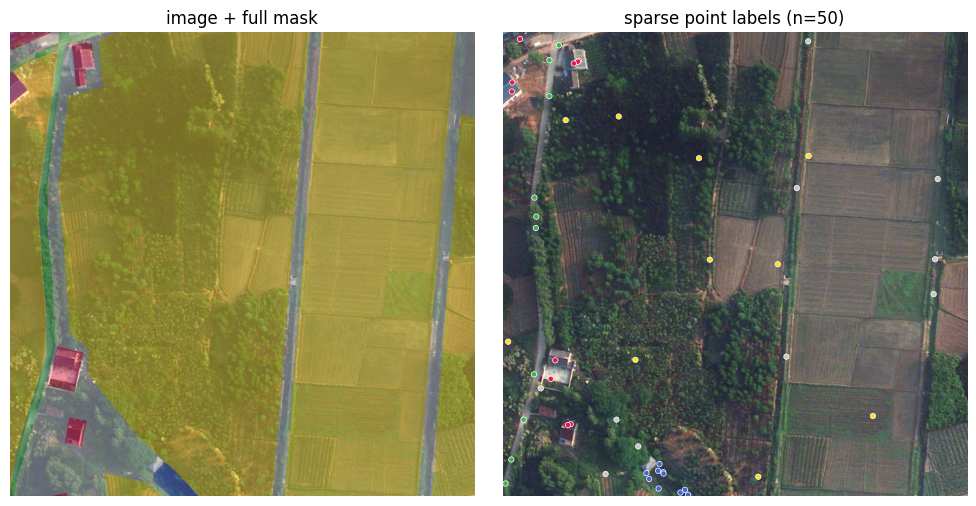

In [12]:
ds = SegmentationDataset(train_images, train_masks, points_per_class=10)
img_t, mask_t, pm_t = ds[0]

img_np = (img_t.permute(1,2,0).numpy() * 255).astype(np.uint8)
mask_np = mask_t.numpy()
pm_np = pm_t.numpy()

fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].imshow(img_np); axes[0].set_title("image + full mask"); axes[0].axis("off")
axes[0].imshow(mask_np, cmap=cmap, vmin=0, vmax=7, alpha=0.4)

axes[1].imshow(img_np)
ys, xs = np.where(pm_np == 1)
colors = [cmap(mask_np[y,x]/7) for y,x in zip(ys,xs)]
axes[1].scatter(xs, ys, c=colors, s=15, edgecolors="white", linewidths=0.5)
axes[1].set_title(f"sparse point labels (n={len(ys)})"); axes[1].axis("off")
plt.tight_layout()
plt.show()

## Partial Cross-Entropy loss

Cross-entropy computed only at pixels carrying a point label, normalized by the number of labeled pixels rather than the total pixel count. Unlabeled pixels contribute zero gradient.

In [13]:
import torch.nn as nn
import torch.nn.functional as F

class PartialCELoss(nn.Module):
    def forward(self, logits, targets, point_mask):
        per_pixel_ce = F.cross_entropy(logits, targets, reduction="none")
        point_mask = point_mask.float()
        return (per_pixel_ce * point_mask).sum() / point_mask.sum().clamp(min=1.0)

## Build datasets, dataloaders, and the segmentation model

Apply a resize transform (nearest-neighbor for masks, to avoid corrupting class labels), construct the train/val datasets and dataloaders, and initialize a U-Net with an ImageNet-pretrained ResNet-34 encoder, the Partial CE loss, and the Adam optimizer.

In [14]:
from torch.utils.data import DataLoader
import segmentation_models_pytorch as smp
import cv2

resize = A.Compose([A.Resize(512, 512, interpolation=cv2.INTER_LINEAR, mask_interpolation=cv2.INTER_NEAREST)])

# Balanced condition
balanced_train_ds = SegmentationDataset(train_images, train_masks, points_per_class=5,strategy="balanced", transform=resize)
balanced_val_ds = SegmentationDataset(val_images, val_masks, points_per_class=5,strategy="balanced", transform=resize)

balanced_train_loader = DataLoader(balanced_train_ds, batch_size=8, shuffle=True, num_workers=2)
balanced_val_loader = DataLoader(balanced_val_ds, batch_size=8, shuffle=False, num_workers=2)

# Random condition — matched to the same average budget (24 points)
random_train_ds = SegmentationDataset(train_images, train_masks, n_random_points=24,strategy="random", transform=resize)
random_val_ds = SegmentationDataset(val_images, val_masks, n_random_points=24,strategy="random", transform=resize)

random_train_loader = DataLoader(random_train_ds, batch_size=8, shuffle=True, num_workers=2)
random_val_loader = DataLoader(random_val_ds, batch_size=8, shuffle=False, num_workers=2)

NUM_CLASSES = len(CLASS_NAMES)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet",
                  in_channels=3, classes=NUM_CLASSES).to(device)
criterion = PartialCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

## Train and evaluate

Train the model for several epochs using only sparse point supervision, and evaluate mean IoU against the full validation masks after each epoch. No-data pixels (class 0) are excluded from the mIoU calculation.

In [28]:
CLASS_NAMES = ["no-data", "background", "building", "road", "water", "barren", "forest", "agriculture"]

@torch.no_grad()
def evaluate_miou(model, loader, n_classes=NUM_CLASSES, verbose=False, return_per_class=False):
    model.eval()
    inter = torch.zeros(n_classes)
    union = torch.zeros(n_classes)
    for images, masks, _ in loader:
        images, masks = images.to(device), masks.to(device)
        preds = model(images).argmax(dim=1)
        for c in range(1, n_classes):
            p, t = (preds == c), (masks == c)
            inter[c] += (p & t).sum().item()
            union[c] += (p | t).sum().item()

    valid = union > 0
    per_class_iou = torch.where(valid, inter / union.clamp(min=1), torch.zeros_like(union))

    if verbose:
        for c in range(1, n_classes):
            status = f"{per_class_iou[c]:.4f}" if valid[c] else "  n/a"
            print(f"  {CLASS_NAMES[c]:12s}: {status}")

    mean_iou = per_class_iou[valid].mean().item()
    if return_per_class:
        return mean_iou, per_class_iou.numpy()
    return mean_iou

In [16]:
def train_model(train_loader, val_loader, epochs=10, tag=""):
    model = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet",
                      in_channels=3, classes=NUM_CLASSES).to(device)
    criterion = PartialCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    history = []
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for images, masks, point_masks in train_loader:
            images, masks, point_masks = images.to(device), masks.to(device), point_masks.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), masks, point_masks)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * images.size(0)

        val_miou = evaluate_miou(model, val_loader)
        print(f"[{tag}] epoch {epoch}: train_loss={total_loss/len(train_loader.dataset):.4f}  val_mIoU={val_miou:.4f}")
        history.append((epoch, total_loss/len(train_loader.dataset), val_miou))

    return model, history

In [37]:
balanced_model, balanced_history = train_model(balanced_train_loader, balanced_val_loader,epochs=10, tag="balanced")

[balanced] epoch 0: train_loss=1.7055  val_mIoU=0.2458
[balanced] epoch 1: train_loss=1.2250  val_mIoU=0.2962
[balanced] epoch 2: train_loss=1.0671  val_mIoU=0.3326
[balanced] epoch 3: train_loss=0.9650  val_mIoU=0.3480
[balanced] epoch 4: train_loss=0.9106  val_mIoU=0.3569
[balanced] epoch 5: train_loss=0.8557  val_mIoU=0.3828
[balanced] epoch 6: train_loss=0.8203  val_mIoU=0.3939
[balanced] epoch 7: train_loss=0.7814  val_mIoU=0.3698
[balanced] epoch 8: train_loss=0.7517  val_mIoU=0.3839
[balanced] epoch 9: train_loss=0.7263  val_mIoU=0.3921


In [38]:
random_model, random_history = train_model(random_train_loader, random_val_loader,epochs=10, tag="random")

[random] epoch 0: train_loss=1.6365  val_mIoU=0.2687
[random] epoch 1: train_loss=1.1246  val_mIoU=0.3803
[random] epoch 2: train_loss=0.9919  val_mIoU=0.4195
[random] epoch 3: train_loss=0.9128  val_mIoU=0.4134
[random] epoch 4: train_loss=0.8792  val_mIoU=0.4228
[random] epoch 5: train_loss=0.8264  val_mIoU=0.4299
[random] epoch 6: train_loss=0.8142  val_mIoU=0.4320
[random] epoch 7: train_loss=0.7629  val_mIoU=0.4068
[random] epoch 8: train_loss=0.7512  val_mIoU=0.4530
[random] epoch 9: train_loss=0.7222  val_mIoU=0.4278


In [41]:
print("BALANCED model:")
evaluate_miou(balanced_model, balanced_val_loader, verbose=True)

print("\nRANDOM model:")
evaluate_miou(random_model, random_val_loader, verbose=True)

BALANCED model:
  background  : 0.3641
  building    : 0.3692
  road        : 0.4276
  water       : 0.5647
  barren      : 0.2937
  forest      : 0.3301
  agriculture : 0.3955

RANDOM model:
  background  : 0.4954
  building    : 0.3473
  road        : 0.4405
  water       : 0.6414
  barren      : 0.2437
  forest      : 0.3500
  agriculture : 0.4762


0.4277981221675873

### Per-class comparison

| Class | Balanced | Random | Winner |
| :--- | :--- | :--- | :--- |
| **background** | 0.3641 | 0.4954 | Random (+0.131) |
| **building** | 0.3692 | 0.3473 | Balanced (+0.022) |
| **road** | 0.4276 | 0.4405 | Random (+0.013) |
| **water** | 0.5647 | 0.6414 | Random (+0.077) |
| **barren** | 0.2937 | 0.2437 | Balanced (+0.050) |
| **forest** | 0.3301 | 0.3500 | Random (+0.020) |
| **agriculture** | 0.3955 | 0.4762 | Random (+0.081) |
| **Mean** | **0.392** | **0.428** | **Random overall** |


In [ ]:
# Balanced condition (2 pts/class)
balanced_train_ds2 = SegmentationDataset(train_images, train_masks, points_per_class=2,strategy="balanced", transform=resize)
balanced_val_ds2 = SegmentationDataset(val_images, val_masks, points_per_class=2,strategy="balanced", transform=resize)

balanced_train_loader2 = DataLoader(balanced_train_ds2, batch_size=8, shuffle=True, num_workers=2)
balanced_val_loader2 = DataLoader(balanced_val_ds2, batch_size=8, shuffle=False, num_workers=2)


In [22]:
# Random condition — matched to the same average budget (~10 points)
random_train_ds2 = SegmentationDataset(train_images, train_masks, n_random_points=10,strategy="random", transform=resize)
random_val_ds2 = SegmentationDataset(val_images, val_masks, n_random_points=10,strategy="random", transform=resize)

random_train_loader2 = DataLoader(random_train_ds2, batch_size=8, shuffle=True, num_workers=2)
random_val_loader2 = DataLoader(random_val_ds2, batch_size=8, shuffle=False, num_workers=2)

In [20]:
balanced_model2, balanced_history2 = train_model(balanced_train_loader2, balanced_val_loader2,epochs=10, tag="balanced_2pt")

[balanced_2pt] epoch 0: train_loss=1.7364  val_mIoU=0.2215
[balanced_2pt] epoch 1: train_loss=1.3161  val_mIoU=0.2840
[balanced_2pt] epoch 2: train_loss=1.1294  val_mIoU=0.3199
[balanced_2pt] epoch 3: train_loss=1.0571  val_mIoU=0.3292
[balanced_2pt] epoch 4: train_loss=0.9972  val_mIoU=0.3465
[balanced_2pt] epoch 5: train_loss=0.9397  val_mIoU=0.3618
[balanced_2pt] epoch 6: train_loss=0.9106  val_mIoU=0.3579
[balanced_2pt] epoch 7: train_loss=0.8811  val_mIoU=0.3748
[balanced_2pt] epoch 8: train_loss=0.8516  val_mIoU=0.3846
[balanced_2pt] epoch 9: train_loss=0.8397  val_mIoU=0.3580


In [23]:
random_model2, random_history2 = train_model(random_train_loader2, random_val_loader2,epochs=10, tag="random_10pt")

[random_10pt] epoch 0: train_loss=1.7310  val_mIoU=0.2532
[random_10pt] epoch 1: train_loss=1.2167  val_mIoU=0.3208
[random_10pt] epoch 2: train_loss=1.0851  val_mIoU=0.3518
[random_10pt] epoch 3: train_loss=1.0093  val_mIoU=0.3551
[random_10pt] epoch 4: train_loss=0.9540  val_mIoU=0.3951
[random_10pt] epoch 5: train_loss=0.9128  val_mIoU=0.3993
[random_10pt] epoch 6: train_loss=0.8934  val_mIoU=0.3934
[random_10pt] epoch 7: train_loss=0.8715  val_mIoU=0.4233
[random_10pt] epoch 8: train_loss=0.8434  val_mIoU=0.4164
[random_10pt] epoch 9: train_loss=0.8179  val_mIoU=0.4270


In [24]:
print("BALANCED2 model:")
evaluate_miou(balanced_model2, balanced_val_loader2, verbose=True)

print("n/RANDOM (10pt) model:")
evaluate_miou(random_model2, random_val_loader2, verbose=True)

BALANCED2 model:
  background  : 0.3123
  building    : 0.3639
  road        : 0.4331
  water       : 0.4937
  barren      : 0.2672
  forest      : 0.2724
  agriculture : 0.3634
n/RANDOM (10pt) model:
  background  : 0.5049
  building    : 0.4756
  road        : 0.4317
  water       : 0.6037
  barren      : 0.1477
  forest      : 0.3172
  agriculture : 0.5085


0.42704081535339355

## Graphical results and analysis

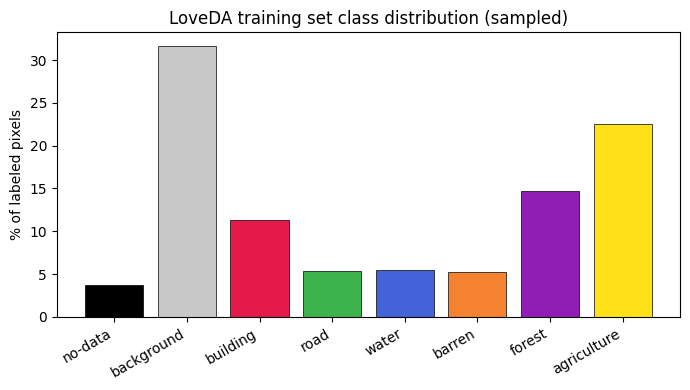

In [25]:
import matplotlib.pyplot as plt

pct = [100 * counts.get(c, 0) / total for c in range(8)]
colors = ["black", "#c8c8c8", "#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4", "#ffe119"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(CLASS_NAMES, pct, color=colors, edgecolor="black", linewidth=0.5)
ax.set_ylabel("% of labeled pixels")
ax.set_title("LoveDA training set class distribution (sampled)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [27]:
bal_epochs = [h[0] for h in balanced_history]
bal_miou = [h[2] for h in balanced_history]
rand_epochs = [h[0] for h in random_history]
rand_miou = [h[2] for h in random_history]

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(bal_epochs, bal_miou, marker="o", label="Class-balanced (5 pts/class)")
ax.plot(rand_epochs, rand_miou, marker="o", label="Random (n=24, matched budget)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation mIoU")
ax.set_title("Training curves at ~24 labeled px/image budget")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'balanced_history' is not defined

In [29]:
import numpy as np

_, bal_pc = evaluate_miou(balanced_model, balanced_val_loader, return_per_class=True)
_, rand_pc = evaluate_miou(random_model, random_val_loader, return_per_class=True)

cls7 = CLASS_NAMES[1:]  # drop no-data
bal_pc7 = bal_pc[1:]
rand_pc7 = rand_pc[1:]

x = np.arange(len(cls7)); w = 0.35
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - w/2, bal_pc7, w, label="Class-balanced")
ax.bar(x + w/2, rand_pc7, w, label="Random (matched)")
ax.set_xticks(x); ax.set_xticklabels(cls7, rotation=20, ha="right")
ax.set_ylabel("Validation IoU")
ax.set_title("Per-class IoU comparison")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

NameError: name 'balanced_model' is not defined

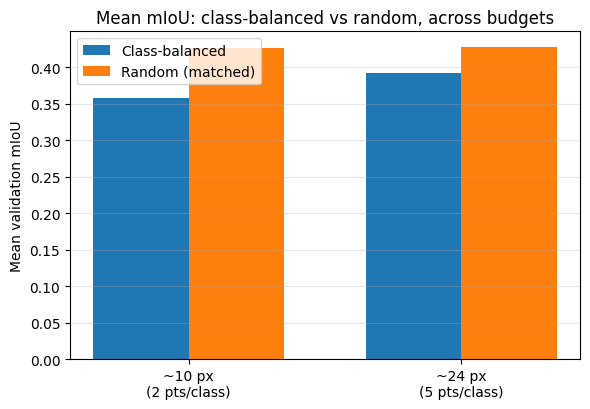

In [30]:
budgets = ["~10 px\n(2 pts/class)", "~24 px\n(5 pts/class)"]
bal_mean = [0.358, 0.392]     # replace with your actual recorded means if they differ
rand_mean = [0.427, 0.428]

x2 = np.arange(len(budgets)); w = 0.35
fig, ax = plt.subplots(figsize=(6, 4.2))
ax.bar(x2 - w/2, bal_mean, w, label="Class-balanced")
ax.bar(x2 + w/2, rand_mean, w, label="Random (matched)")
ax.set_xticks(x2); ax.set_xticklabels(budgets)
ax.set_ylabel("Mean validation mIoU")
ax.set_title("Mean mIoU: class-balanced vs random, across budgets")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## Model saving

In [30]:
torch.save(model.state_dict(), "/kaggle/working/model.pt")